# Notebook 05 — SARIMAX with Weather Regressors
**Station: Hirsch · Base model: SARIMAX(2,1,2)(1,0,2)[7] + Fourier K=4**

Notebook 04 showed that adding Fourier annual terms cut RMSE from ~1308 to ~491 (test 7-day). This notebook tests whether adding weather variables as additional exogenous regressors can push performance further.

| Part | Content |
|------|---------|
| 1 | Data loading and weather feature preparation |
| 2 | Model configurations (6 variants: baseline + 5 weather combos) |
| 3 | Fit and evaluate all configurations |
| 4 | Comparison table and bar chart |
| 5 | Decision framework (keep/drop criteria) |
| 6 | Coefficient analysis for best model |
| 7 | Residual diagnostics for best model |
| 8 | Final comparison vs all prior baselines |


In [1]:
import sys, warnings, time, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import probplot

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

plt.rcParams.update({
    'figure.dpi'       : 120,
    'font.size'        : 11,
    'axes.labelsize'   : 12,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'legend.frameon'   : False,
})
sns.set_theme(style='whitegrid')

FIGURES = Path('../results/figures')
TABLES  = Path('../results/tables')
MODELS  = Path('../results/models')
PREDS   = Path('../results/predictions')
for p in [FIGURES, TABLES, MODELS, PREDS]:
    p.mkdir(parents=True, exist_ok=True)

# ── Model constants (confirmed best in notebooks 03–04) ───────────────────
ORDER          = (2, 1, 2)
SEASONAL_ORDER = (1, 0, 2, 7)
ANNUAL_PERIOD  = 365.25
REF_DATE       = '2013-01-01'

STATION    = 'Hirsch'
TRAIN_START, TRAIN_END = '2013-01-01', '2022-12-31'
VAL_START,   VAL_END   = '2023-01-01', '2023-12-31'
TEST_START,  TEST_END  = '2024-01-01', '2026-04-30'

WEATHER_COLS = ['max_temp', 'sunshine_hours', 'precipitation']

# ── Load nb04 results to avoid hardcoded upstream values ──────────────────
fourier_comp   = pd.read_csv(TABLES / 'fourier_comparison.csv')
_best_val_rmse = fourier_comp['val_7d_RMSE'].min()
_candidates    = fourier_comp[fourier_comp['val_7d_RMSE'] <= _best_val_rmse + 5].sort_values('K')
OPTIMAL_K      = int(_candidates.iloc[0]['K'])
_opt_row       = fourier_comp.loc[fourier_comp['K'] == OPTIMAL_K].iloc[0]
NB04_VAL_RMSE  = float(_opt_row['val_7d_RMSE'])
NB04_TEST_RMSE = float(_opt_row['test_7d_RMSE'])

np.random.seed(42)

# ── notebook prefix: all figures saved as nb05_<name>.png ────────────────────
NB = 'nb05'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

print(f'Setup complete.  OPTIMAL_K={OPTIMAL_K}  NB04_VAL_RMSE={NB04_VAL_RMSE}  NB04_TEST_RMSE={NB04_TEST_RMSE}')

Setup complete.  OPTIMAL_K=4  NB04_VAL_RMSE=489.7  NB04_TEST_RMSE=497.8


---
## Part 1 — Data Loading and Weather Feature Preparation

Weather variables used (from München open data, station-level daily):

| Variable | Correlation with counts | Transform | Reason |
|----------|------------------------|-----------|--------|
| `max_temp` | r = 0.62 | raw | approximately normal, −8 to 37°C |
| `sunshine_hours` | r = 0.51 | raw | 0–15.7h, reasonably symmetric |
| `precipitation` | r = −0.12 | log1p | highly right-skewed, many zeros |

Excluded: `min_temp` (collinear with `max_temp`), `cloud_cover` (collinear with `sunshine_hours`).

In [2]:
from data_loader import load_master_data

df_full = load_master_data('../data/processed/master_bike_data.csv')
hirsch_full = (
    df_full[df_full['station'] == STATION]
    .set_index('date')
    .sort_index()
)

# ── Bike counts ──────────────────────────────────────────────────────────
hirsch = hirsch_full['total']
train  = hirsch[TRAIN_START:TRAIN_END].copy()
val    = hirsch[VAL_START  :VAL_END  ].copy()
test   = hirsch[TEST_START :TEST_END ].copy()

# ── Continuous train series (fill any residual gaps) ─────────────────────
train_full = train.reindex(
    pd.date_range(TRAIN_START, TRAIN_END, freq='D')
).interpolate(method='linear', limit=7)

tv_index  = pd.date_range(TRAIN_START, VAL_END, freq='D')
tv_series = (
    pd.concat([train_full, val])
    .reindex(tv_index)
    .interpolate(method='linear', limit=7)
)

# ── Weather: apply log1p to precipitation (right-skewed) ──────────────────
weather_raw = hirsch_full[WEATHER_COLS].copy()
weather = weather_raw.copy()
weather['precipitation'] = np.log1p(weather_raw['precipitation'])

w_train = weather.reindex(train_full.index).ffill().bfill()
w_val   = weather.reindex(val.index)
w_test  = weather.reindex(test.index)
w_tv    = weather.reindex(tv_index).ffill().bfill()

for name, split in [('Train', train), ('Val', val), ('Test', test)]:
    print(f'{name:<6} {split.index[0].date()} → {split.index[-1].date()}  '
          f'({len(split):,} days  |  missing: {split.isna().sum()})')

print('\nWeather splits — missing values:')
for name, w in [('train', w_train), ('val', w_val), ('test', w_test)]:
    print(f'  {name}: {w.isna().sum().to_dict()}')

print('\nWeather stats (train period, after log1p on precipitation):')
print(w_train.describe().round(3))

Train  2013-01-01 → 2022-12-31  (3,652 days  |  missing: 0)
Val    2023-01-01 → 2023-12-31  (365 days  |  missing: 0)
Test   2024-01-01 → 2026-04-30  (851 days  |  missing: 0)

Weather splits — missing values:
  train: {'max_temp': 0, 'sunshine_hours': 0, 'precipitation': 0}
  val: {'max_temp': 0, 'sunshine_hours': 0, 'precipitation': 0}
  test: {'max_temp': 0, 'sunshine_hours': 0, 'precipitation': 0}

Weather stats (train period, after log1p on precipitation):
       max_temp  sunshine_hours  precipitation
count  3652.000        3652.000       3652.000
mean     15.226           5.289          0.634
std       8.998           4.680          0.928
min      -8.100           0.000          0.000
25%       7.900           0.600          0.000
50%      15.350           4.350          0.000
75%      22.300           9.300          1.163
max      36.900          15.700          4.279


---
## Part 2 — Fourier Terms and Model Configurations

The exogenous regressor matrix for each model is:
```
exog = [sin_1, cos_1, ..., sin_4, cos_4  |  weather_var_1, ..., weather_var_N]
        ← 8 Fourier columns (K=4) →          ← 0–3 weather columns →
```
The Fourier terms are identical across all 6 configurations — weather columns only add to them.

In [3]:
def create_fourier_terms(dates, K, period=365.25, ref_date='2013-01-01'):
    """
    K sin/cos pairs anchored to ref_date for phase continuity across splits.
    K=0 returns an empty DataFrame.
    """
    dates = pd.DatetimeIndex(dates)
    if K == 0:
        return pd.DataFrame(index=dates)
    t = (dates - pd.Timestamp(ref_date)).days.values.astype(float)
    cols = {}
    for k in range(1, K + 1):
        angle = 2 * np.pi * k * t / period
        cols[f'sin_{k}'] = np.sin(angle)
        cols[f'cos_{k}'] = np.cos(angle)
    return pd.DataFrame(cols, index=dates)


# ── Pre-generate Fourier features for K=OPTIMAL_K ────────────────────────
fourier = {
    'train': create_fourier_terms(train_full.index, OPTIMAL_K),
    'val'  : create_fourier_terms(val.index,        OPTIMAL_K),
    'test' : create_fourier_terms(test.index,       OPTIMAL_K),
    'tv'   : create_fourier_terms(tv_index,         OPTIMAL_K),
}

# ── Model configurations ─────────────────────────────────────────────────
MODEL_CONFIGS = [
    {'id': 'baseline',        'label': f'Fourier K={OPTIMAL_K} only',                                  'weather': []},
    {'id': 'max_temp',        'label': f'Fourier K={OPTIMAL_K} + max_temp',                            'weather': ['max_temp']},
    {'id': 'sunshine_hours',  'label': f'Fourier K={OPTIMAL_K} + sunshine_hours',                      'weather': ['sunshine_hours']},
    {'id': 'precipitation',   'label': f'Fourier K={OPTIMAL_K} + precipitation',                       'weather': ['precipitation']},
    {'id': 'temp_sun',        'label': f'Fourier K={OPTIMAL_K} + max_temp + sunshine_hours',           'weather': ['max_temp', 'sunshine_hours']},
    {'id': 'all_weather',     'label': f'Fourier K={OPTIMAL_K} + all weather',                         'weather': ['max_temp', 'sunshine_hours', 'precipitation']},
]

print(f'{len(MODEL_CONFIGS)} configurations (all built on SARIMAX{ORDER}{SEASONAL_ORDER})\n')
print(f'{"ID":<18}  {"Exog total":>10}  Weather regressors')
print('-' * 60)
for cfg in MODEL_CONFIGS:
    n_exog = 2 * OPTIMAL_K + len(cfg['weather'])
    print(f'{cfg["id"]:<18}  {n_exog:>10}  {cfg["weather"]}')

6 configurations (all built on SARIMAX(2, 1, 2)(1, 0, 2, 7))

ID                  Exog total  Weather regressors
------------------------------------------------------------
baseline                     8  []
max_temp                     9  ['max_temp']
sunshine_hours               9  ['sunshine_hours']
precipitation                9  ['precipitation']
temp_sun                    10  ['max_temp', 'sunshine_hours']
all_weather                 11  ['max_temp', 'sunshine_hours', 'precipitation']


---
## Part 3 — Fit and Evaluate All Configurations

Each configuration is:
1. Fit on `train` (2013–2022) → forecast `val` (2023)
2. Refit on `train+val` with warm start → forecast `test` (2024–2025)

Evaluation uses non-overlapping h-day windows (h=7 and h=30).

In [4]:
def evaluate_forecast(y_true, y_pred, horizon):
    """RMSE, MAE, MAPE over non-overlapping h-day windows."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmses, maes, mapes = [], [], []
    for i in range(0, len(y_true), horizon):
        yt = y_true[i:i + horizon]
        yp = y_pred[i:i + horizon]
        if len(yt) < max(1, horizon // 2):
            continue
        rmses.append(np.sqrt(np.mean((yt - yp) ** 2)))
        maes.append(np.mean(np.abs(yt - yp)))
        nonzero = yt > 0
        if nonzero.sum() > 0:
            mapes.append(
                np.mean(np.abs((yt[nonzero] - yp[nonzero]) / yt[nonzero])) * 100
            )
    return {
        'RMSE': round(float(np.mean(rmses)), 1),
        'MAE' : round(float(np.mean(maes)),  1),
        'MAPE': round(float(np.mean(mapes)), 1) if mapes else np.nan,
    }


def build_exog(split_key, weather_cols):
    """Concatenate Fourier K=4 columns and requested weather columns."""
    f = fourier[split_key]
    w_map = {'train': w_train, 'val': w_val, 'test': w_test, 'tv': w_tv}
    if not weather_cols:
        return f   # Fourier only (K=4, 8 columns)
    w = w_map[split_key][weather_cols]
    return pd.concat([f, w], axis=1)


results   = []
fit_store = {}   # fit_store[cfg_id] = {fit_train, fit_tv, val_preds, test_preds}

print(f'{"Configuration":<47}  {"val 7d":>7}  {"test 7d":>8}  {"Δtest%":>7}  {"AIC":>9}  time')
print('-' * 95)

for cfg in MODEL_CONFIGS:
    cfg_id = cfg['id']
    wcols  = cfg['weather']

    exog_train = build_exog('train', wcols)
    exog_val   = build_exog('val',   wcols)
    exog_test  = build_exog('test',  wcols)
    exog_tv    = build_exog('tv',    wcols)

    t0 = time.time()

    # Fit on train
    m_train = SARIMAX(
        train_full, exog=exog_train,
        order=ORDER, seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False, trend='c'
    )
    fit_train = m_train.fit(disp=False, maxiter=300)
    vp = np.maximum(fit_train.forecast(steps=len(val), exog=exog_val).values, 0)

    # Refit on train+val (warm start from train params)
    m_tv = SARIMAX(
        tv_series, exog=exog_tv,
        order=ORDER, seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False, trend='c'
    )
    fit_tv = m_tv.fit(start_params=fit_train.params, disp=False, maxiter=300)
    tp = np.maximum(fit_tv.forecast(steps=len(test), exog=exog_test).values, 0)

    fit_store[cfg_id] = {
        'fit_train' : fit_train,
        'fit_tv'    : fit_tv,
        'val_preds' : vp,
        'test_preds': tp,
    }

    elapsed = time.time() - t0

    for h in [7, 30]:
        vm = evaluate_forecast(val.values,  vp, h)
        tm = evaluate_forecast(test.values, tp, h)
        for split_name, m in [('val', vm), ('test', tm)]:
            results.append({
                'config_id'   : cfg_id,
                'label'       : cfg['label'],
                'weather'     : ', '.join(wcols) if wcols else 'none',
                'n_weather'   : len(wcols),
                'n_exog_total': exog_train.shape[1],
                'Horizon'     : f'{h}-day',
                'Split'       : split_name,
                'AIC'         : round(fit_train.aic, 1),
                'BIC'         : round(fit_train.bic, 1),
                'fit_time_s'  : round(elapsed, 1),
                **m,
            })

    vm7 = evaluate_forecast(val.values,  vp, 7)
    tm7 = evaluate_forecast(test.values, tp, 7)
    delta = (NB04_TEST_RMSE - tm7['RMSE']) / NB04_TEST_RMSE * 100
    conv = '⚠' if not getattr(fit_train.mle_retvals, 'get', lambda k, d: True)('converged', True) else ' '
    print(f'{conv} {cfg["label"]:<45}  {vm7["RMSE"]:>7.1f}  {tm7["RMSE"]:>8.1f}  '
          f'{delta:>+7.1f}%  {fit_train.aic:>9.1f}  {elapsed:.0f}s')

Configuration                                     val 7d   test 7d   Δtest%        AIC  time
-----------------------------------------------------------------------------------------------


  Fourier K=4 only                                 489.7     497.8     +0.0%    53121.7  55s


  Fourier K=4 + max_temp                           532.6     931.5    -87.1%    51949.4  81s


  Fourier K=4 + sunshine_hours                     450.4     479.3     +3.7%    51301.7  54s


  Fourier K=4 + precipitation                      472.6     626.6    -25.9%    52510.6  44s


  Fourier K=4 + max_temp + sunshine_hours          456.7     480.9     +3.4%    51031.1  58s


  Fourier K=4 + all weather                        447.2     471.0     +5.4%    50690.2  65s


---
## Part 4 — Comparison Table and Bar Chart

In [5]:
results_df = pd.DataFrame(results)

summary_rows = []
for cfg in MODEL_CONFIGS:
    cid = cfg['id']
    sub = results_df[results_df['config_id'] == cid]

    v7  = sub[(sub['Split']=='val')  & (sub['Horizon']=='7-day' )].iloc[0]
    v30 = sub[(sub['Split']=='val')  & (sub['Horizon']=='30-day')].iloc[0]
    t7  = sub[(sub['Split']=='test') & (sub['Horizon']=='7-day' )].iloc[0]
    t30 = sub[(sub['Split']=='test') & (sub['Horizon']=='30-day')].iloc[0]

    summary_rows.append({
        'config_id'          : cid,
        'Weather vars'       : v7['weather'],
        'Total exog'         : v7['n_exog_total'],
        'AIC'                : v7['AIC'],
        'BIC'                : v7['BIC'],
        'Val 7d RMSE'        : v7['RMSE'],
        'Val 30d RMSE'       : v30['RMSE'],
        'Test 7d RMSE'       : t7['RMSE'],
        'Test 30d RMSE'      : t30['RMSE'],
        'Val 7d MAE'         : v7['MAE'],
        'Test 7d MAE'        : t7['MAE'],
        'Δ vs nb04 test (%)' : round((NB04_TEST_RMSE - t7['RMSE']) / NB04_TEST_RMSE * 100, 1),
        'Fit time (s)'       : v7['fit_time_s'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Test 7d RMSE').reset_index(drop=True)

# Select best config id
best_cfg_id = summary_df.iloc[0]['config_id']
best_cfg    = next(c for c in MODEL_CONFIGS if c['id'] == best_cfg_id)

print('=== SARIMAX Weather Comparison — Hirsch, 7-day RMSE ===')
display_df = summary_df.drop(columns='config_id')
print(display_df.to_string(index=False))

# Save (without internal config_id column)
display_df.to_csv(TABLES / 'weather_comparison.csv', index=False)
print(f'\nSaved → results/tables/weather_comparison.csv')
print(f'Best model: {best_cfg["label"]}  (test 7d RMSE = {summary_df.iloc[0]["Test 7d RMSE"]:.1f})')

=== SARIMAX Weather Comparison — Hirsch, 7-day RMSE ===
                           Weather vars  Total exog     AIC     BIC  Val 7d RMSE  Val 30d RMSE  Test 7d RMSE  Test 30d RMSE  Val 7d MAE  Test 7d MAE  Δ vs nb04 test (%)  Fit time (s)
max_temp, sunshine_hours, precipitation          11 50690.2 50814.1        447.2         465.3         471.0          481.5       376.2        403.3                 5.4          65.2
                         sunshine_hours           9 51301.7 51413.3        450.4         472.0         479.3          491.4       381.5        411.4                 3.7          54.4
               max_temp, sunshine_hours          10 51031.1 51148.9        456.7         474.7         480.9          491.2       387.6        413.3                 3.4          58.4
                                   none           8 53121.7 53227.1        489.7         509.4         497.8          507.9       420.7        420.8                 0.0          55.0
                          pre

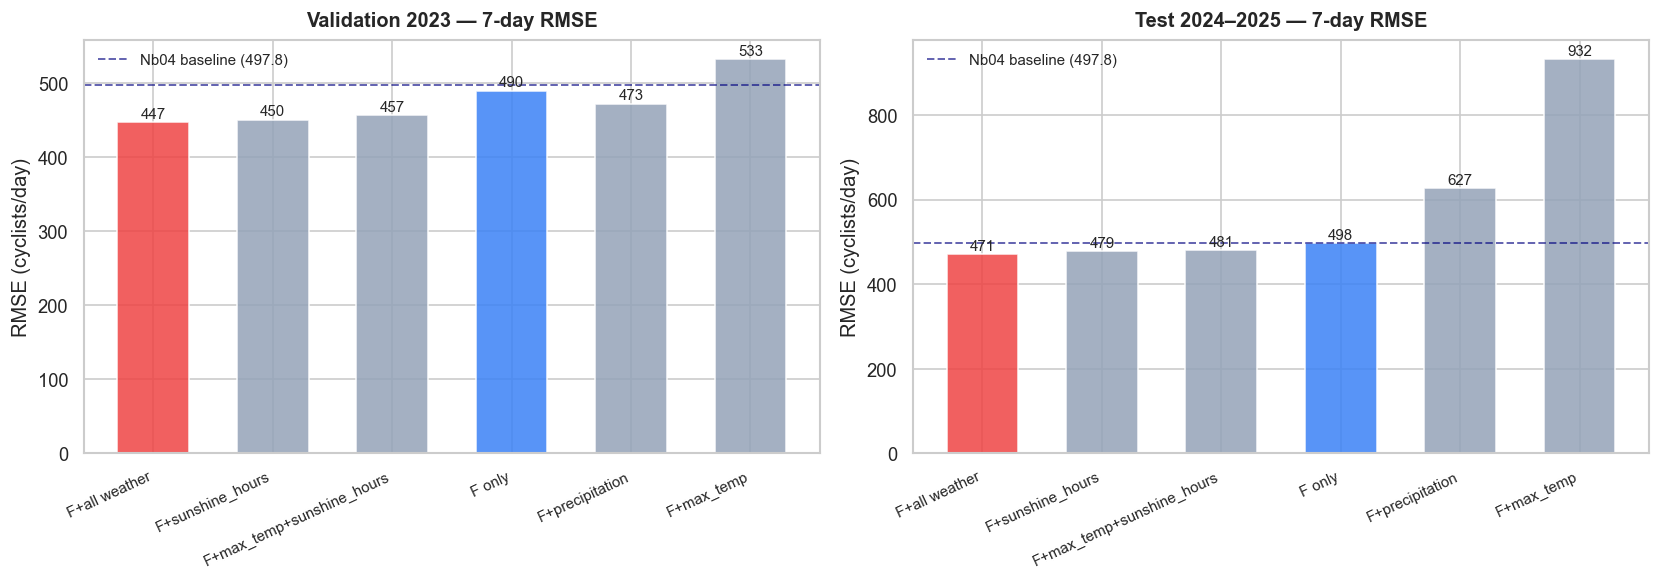

  saved → results/figures/nb05_fig_01_weather_rmse_comparison.png


In [6]:
# ── Bar chart: RMSE for all configs on val and test ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by test RMSE for display
plot_df = summary_df.sort_values('Test 7d RMSE').reset_index(drop=True)
labels  = [c['label'].replace(f'Fourier K={OPTIMAL_K}', 'F').replace(' + ', '+') for c in
           [next(m for m in MODEL_CONFIGS if m['id'] == r) for r in plot_df['config_id']]]

for ax, (col, title) in zip(axes, [
    ('Val 7d RMSE',  'Validation 2023 — 7-day RMSE'),
    ('Test 7d RMSE', 'Test 2024–2025 — 7-day RMSE'),
]):
    colors = ['#ef4444' if r == best_cfg_id else
              '#94a3b8' if r != 'baseline' else '#3b82f6'
              for r in plot_df['config_id']]
    bars = ax.bar(labels, plot_df[col], color=colors, alpha=0.85, width=0.6)
    ax.axhline(NB04_TEST_RMSE, color='navy', ls='--', lw=1.2, alpha=0.6,
               label=f'Nb04 baseline ({NB04_TEST_RMSE:.1f})')
    ax.set_title(title, pad=8)
    ax.set_ylabel('RMSE (cyclists/day)')
    ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    for bar, rmse_v in zip(bars, plot_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{rmse_v:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
savefig('fig_01_weather_rmse_comparison')

---
## Part 5 — Decision Framework

Rules applied to each individual weather variable:

| Rule | Threshold | Action |
|------|-----------|--------|
| Strong improvement | val RMSE ↓ >3% **AND** p-value <0.05 | **KEEP** |
| Marginal | val RMSE ↓ 1–3% | **KEEP WITH CAUTION** |
| No improvement | val RMSE ↓ <1% **OR** test RMSE worse | **DROP** |

Note: p-values from the train-period model summary.

In [7]:
print(f'Baseline (nb04):  val RMSE = {NB04_VAL_RMSE}  |  test RMSE = {NB04_TEST_RMSE}\n')
print(f'{"Config":<45}  {"val Δ%":>7}  {"test Δ%":>8}  {"p-values"}')
print('-' * 90)

decisions = []
for cfg in MODEL_CONFIGS[1:]:   # skip baseline
    cid   = cfg['id']
    wcols = cfg['weather']
    sub   = results_df[results_df['config_id'] == cid]

    v7 = sub[(sub['Split']=='val')  & (sub['Horizon']=='7-day')].iloc[0]
    t7 = sub[(sub['Split']=='test') & (sub['Horizon']=='7-day')].iloc[0]

    val_imp  = (NB04_VAL_RMSE  - v7['RMSE']) / NB04_VAL_RMSE  * 100
    test_imp = (NB04_TEST_RMSE - t7['RMSE']) / NB04_TEST_RMSE * 100

    # Collect p-values for weather regressors from train model
    fit_t   = fit_store[cid]['fit_train']
    p_vals  = {}
    for wc in wcols:
        matches = [p for p in fit_t.param_names if wc in p]
        if matches:
            p_vals[wc] = round(float(fit_t.pvalues[matches[0]]), 4)

    all_sig = all(p < 0.05 for p in p_vals.values()) if p_vals else False

    if test_imp < 0:
        verdict = 'DROP — test RMSE worse'
    elif val_imp < 1.0:
        verdict = 'DROP — <1% val improvement'
    elif val_imp >= 3.0 and all_sig:
        verdict = 'KEEP — >3% val improvement + significant'
    elif val_imp >= 3.0 and not all_sig:
        verdict = 'KEEP WITH CAUTION — >3% improvement but p≥0.05'
    else:
        verdict = 'MARGINAL — 1–3% improvement'

    decisions.append({'config_id': cid, 'verdict': verdict,
                      'val_imp': val_imp, 'test_imp': test_imp, 'p_vals': p_vals})

    p_str = '  '.join(f'{k}:{v:.4f}' for k, v in p_vals.items())
    print(f'{cfg["label"]:<45}  {val_imp:>+7.1f}%  {test_imp:>+8.1f}%  {p_str}')
    print(f'  → {verdict}\n')

Baseline (nb04):  val RMSE = 489.7  |  test RMSE = 497.8

Config                                          val Δ%   test Δ%  p-values
------------------------------------------------------------------------------------------
Fourier K=4 + max_temp                            -8.8%     -87.1%  max_temp:0.0000
  → DROP — test RMSE worse

Fourier K=4 + sunshine_hours                      +8.0%      +3.7%  sunshine_hours:0.0000
  → KEEP — >3% val improvement + significant

Fourier K=4 + precipitation                       +3.5%     -25.9%  precipitation:0.0000
  → DROP — test RMSE worse

Fourier K=4 + max_temp + sunshine_hours           +6.7%      +3.4%  max_temp:0.0000  sunshine_hours:0.0000
  → KEEP — >3% val improvement + significant

Fourier K=4 + all weather                         +8.7%      +5.4%  max_temp:0.0000  sunshine_hours:0.0000  precipitation:0.0000
  → KEEP — >3% val improvement + significant



---
## Part 6 — Coefficient Analysis for Best Model

Interpretation of weather regressor coefficients:
- **max_temp**: Δ cyclists per 1°C increase in daily maximum temperature
- **sunshine_hours**: Δ cyclists per 1 additional sunshine hour
- **precipitation**: Δ cyclists per unit increase in log1p(mm precipitation)
  (since we applied log1p, not directly interpretable in mm — see note below)

In [8]:
best_fit = fit_store[best_cfg_id]['fit_train']
print(f'Best model: {best_cfg["label"]}')
print(f'Test 7d RMSE: {summary_df.iloc[0]["Test 7d RMSE"]:.1f}  '
      f'(vs nb04 baseline {NB04_TEST_RMSE})\n')
print(best_fit.summary())

Best model: Fourier K=4 + all weather
Test 7d RMSE: 471.0  (vs nb04 baseline 497.8)

                                     SARIMAX Results                                     
Dep. Variable:                             total   No. Observations:                 3652
Model:             SARIMAX(2, 1, 2)x(1, 0, 2, 7)   Log Likelihood              -25325.081
Date:                           Mon, 25 May 2026   AIC                          50690.161
Time:                                   20:10:49   BIC                          50814.123
Sample:                               01-01-2013   HQIC                         50734.317
                                    - 12-31-2022                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          0.0001    

In [9]:
# ── Extract weather coefficients and confidence intervals ────────────────
wcols_best = best_cfg['weather']

if wcols_best:
    print(f'\n=== Weather Regressor Coefficients ({best_cfg["label"]}) ===\n')
    for wc in wcols_best:
        matches = [p for p in best_fit.param_names if wc in p]
        if not matches:
            continue
        pname = matches[0]
        coef  = best_fit.params[pname]
        se    = best_fit.bse[pname]
        pval  = best_fit.pvalues[pname]
        ci    = best_fit.conf_int()
        ci_lo = float(ci.loc[pname].iloc[0])
        ci_hi = float(ci.loc[pname].iloc[1])

        if wc == 'max_temp':
            interp = f'1°C higher max temp  →  {coef:+.1f} cyclists/day'
        elif wc == 'sunshine_hours':
            interp = f'1h more sunshine     →  {coef:+.1f} cyclists/day'
        elif wc == 'precipitation':
            interp = (f'log1p(rain) unit ↑  →  {coef:+.1f} cyclists/day'
                      f'  (≈ {coef/np.log1p(10):+.0f} per 10mm rain)')
        else:
            interp = f'unit increase → {coef:+.1f} cyclists/day'

        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f'  {wc:<15}  coef={coef:+8.2f}  SE={se:.2f}  '
              f'p={pval:.4f} {sig}  95%CI=[{ci_lo:.2f}, {ci_hi:.2f}]')
        print(f'  Interpretation: {interp}\n')
else:
    print('Best model has no weather regressors (baseline wins).')


=== Weather Regressor Coefficients (Fourier K=4 + all weather) ===

  max_temp         coef=  +26.74  SE=1.83  p=0.0000 ***  95%CI=[23.14, 30.33]
  Interpretation: 1°C higher max temp  →  +26.7 cyclists/day

  sunshine_hours   coef=  +37.53  SE=1.74  p=0.0000 ***  95%CI=[34.11, 40.95]
  Interpretation: 1h more sunshine     →  +37.5 cyclists/day

  precipitation    coef=  -85.73  SE=6.28  p=0.0000 ***  95%CI=[-98.04, -73.41]
  Interpretation: log1p(rain) unit ↑  →  -85.7 cyclists/day  (≈ -36 per 10mm rain)



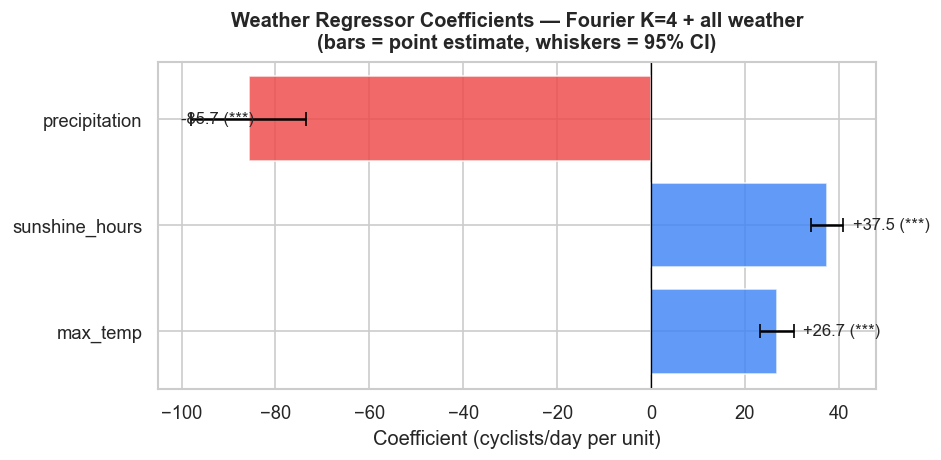

  saved → results/figures/nb05_fig_02_weather_coefficients.png


In [10]:
# ── Coefficient bar chart with confidence intervals ──────────────────────
if wcols_best:
    fig, ax = plt.subplots(figsize=(8, 4))

    coef_data = []
    for wc in wcols_best:
        matches = [p for p in best_fit.param_names if wc in p]
        if matches:
            pname = matches[0]
            coef_data.append({
                'var' : wc,
                'coef': best_fit.params[pname],
                'se'  : best_fit.bse[pname],
                'pval': best_fit.pvalues[pname],
            })

    coef_df = pd.DataFrame(coef_data)
    colors  = ['#3b82f6' if c > 0 else '#ef4444' for c in coef_df['coef']]
    bars    = ax.barh(coef_df['var'], coef_df['coef'], color=colors, alpha=0.8)
    ax.errorbar(coef_df['coef'], coef_df['var'],
                xerr=1.96 * coef_df['se'], fmt='none', color='black', capsize=4, lw=1.5)
    ax.axvline(0, color='black', lw=0.8)

    for bar, row in zip(bars, coef_df.itertuples()):
        sig = '***' if row.pval < 0.001 else '**' if row.pval < 0.01 else '*' if row.pval < 0.05 else 'ns'
        x   = row.coef + (1.96 * row.se + 2) * (1 if row.coef >= 0 else -1)
        ax.text(x, bar.get_y() + bar.get_height()/2,
                f'{row.coef:+.1f} ({sig})', va='center', fontsize=10)

    ax.set_xlabel('Coefficient (cyclists/day per unit)')
    ax.set_title(f'Weather Regressor Coefficients — {best_cfg["label"]}\n'
                 f'(bars = point estimate, whiskers = 95% CI)', pad=8)
    plt.tight_layout()
    savefig('fig_02_weather_coefficients')
else:
    print('No weather regressors in best model — skipping coefficient plot.')

---
## Part 7 — Residual Diagnostics for Best Model

Check whether weather regressors removed additional autocorrelation that the Fourier-only model left behind.

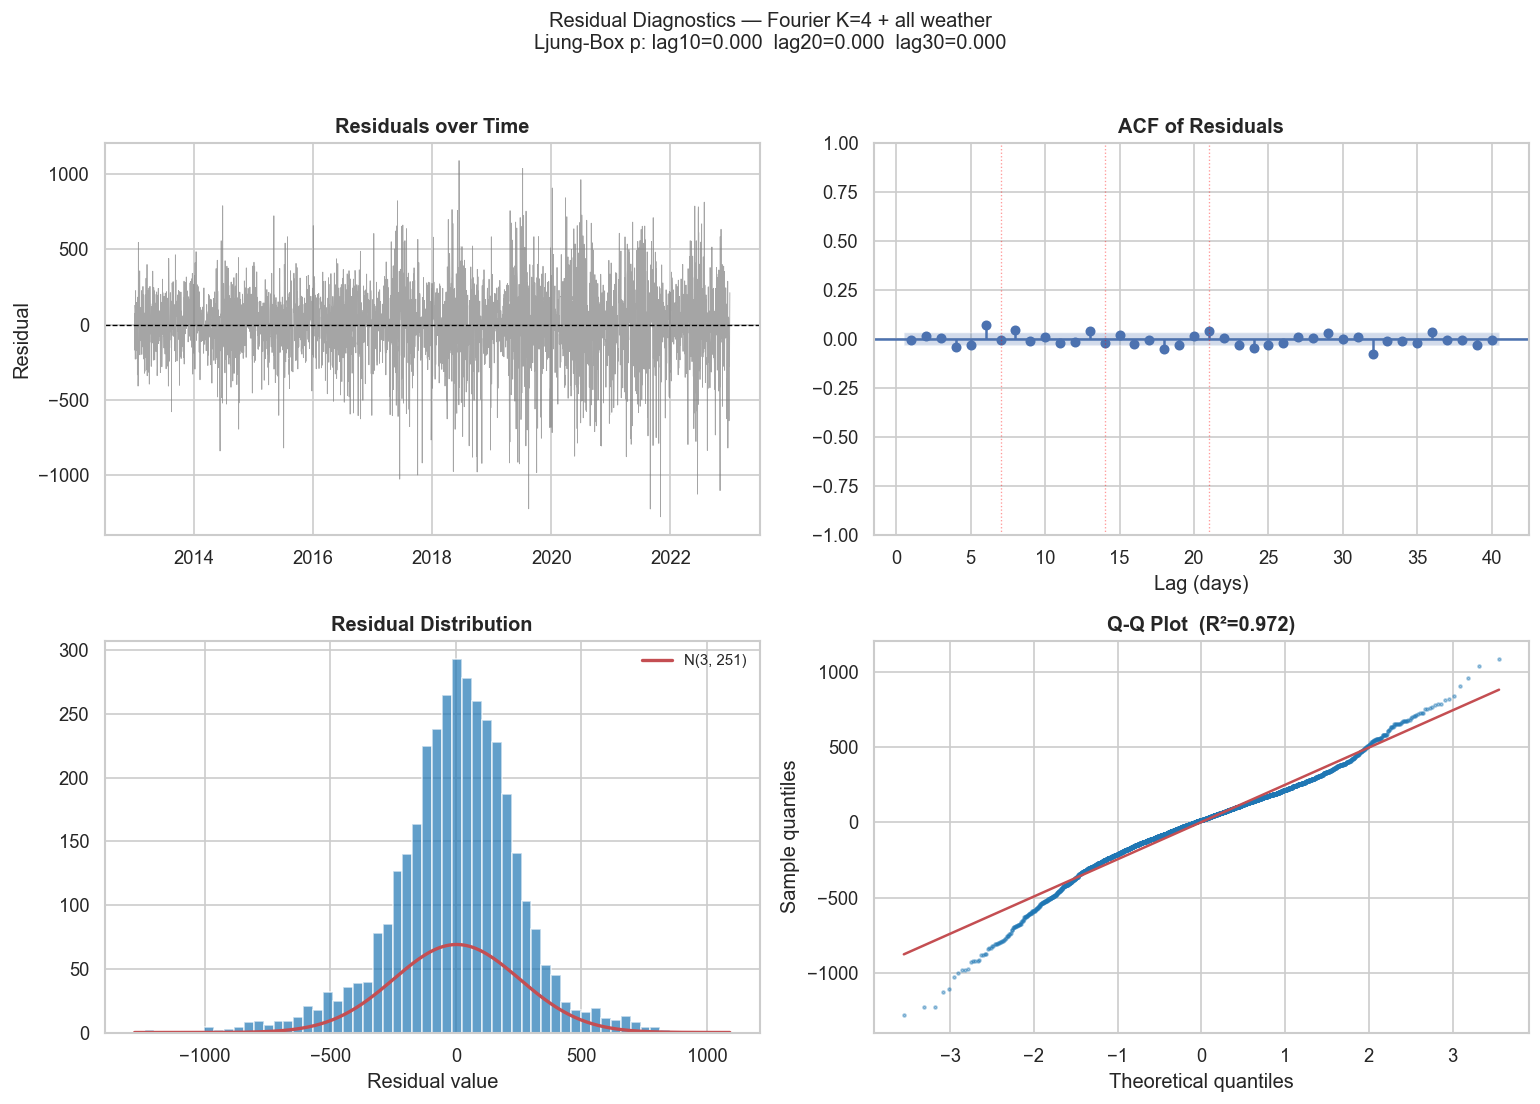

  saved → results/figures/nb05_fig_03_weather_diagnostics.png

Ljung-Box test results:
      lb_stat     lb_pvalue
10  35.686802  9.526941e-05
20  63.421591  2.077309e-06
30  89.540850  7.707595e-08


In [11]:
fit_diag = fit_store[best_cfg_id]['fit_train']
resid    = fit_diag.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Residuals over time
ax = axes[0, 0]
ax.plot(resid.index, resid.values, color='#7f7f7f', lw=0.5, alpha=0.7)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Residuals over Time')
ax.set_ylabel('Residual')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 2. ACF (lags 0–40; weekly lags marked)
ax = axes[0, 1]
plot_acf(resid.dropna(), lags=40, ax=ax, alpha=0.05, zero=False)
ax.set_title('ACF of Residuals')
ax.set_xlabel('Lag (days)')
for lag in [7, 14, 21]:
    ax.axvline(lag, color='red', ls=':', alpha=0.4, lw=0.8)

# 3. Residual histogram
ax = axes[1, 0]
ax.hist(resid.dropna(), bins=60, color='#1f77b4', alpha=0.7, edgecolor='white')
mu, sigma = resid.dropna().mean(), resid.dropna().std()
xs = np.linspace(resid.min(), resid.max(), 200)
ax.plot(xs, len(resid) * (xs[1] - xs[0]) * stats.norm.pdf(xs, mu, sigma),
        'r-', lw=2, label=f'N({mu:.0f}, {sigma:.0f})')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual value')
ax.legend(fontsize=9)

# 4. Q-Q plot
ax = axes[1, 1]
(osm, osr), (slope, intercept, r) = probplot(resid.dropna(), dist='norm')
ax.scatter(osm, osr, s=3, alpha=0.4, color='#1f77b4')
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=1.5)
ax.set_title(f'Q-Q Plot  (R²={r**2:.3f})')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')

lb = acorr_ljungbox(resid.dropna(), lags=[10, 20, 30], return_df=True)
fig.suptitle(
    f'Residual Diagnostics — {best_cfg["label"]}\n'
    f'Ljung-Box p: lag10={lb["lb_pvalue"].iloc[0]:.3f}  '
    f'lag20={lb["lb_pvalue"].iloc[1]:.3f}  '
    f'lag30={lb["lb_pvalue"].iloc[2]:.3f}',
    fontsize=12, y=1.02
)
plt.tight_layout()
savefig('fig_03_weather_diagnostics')

print('\nLjung-Box test results:')
print(lb)

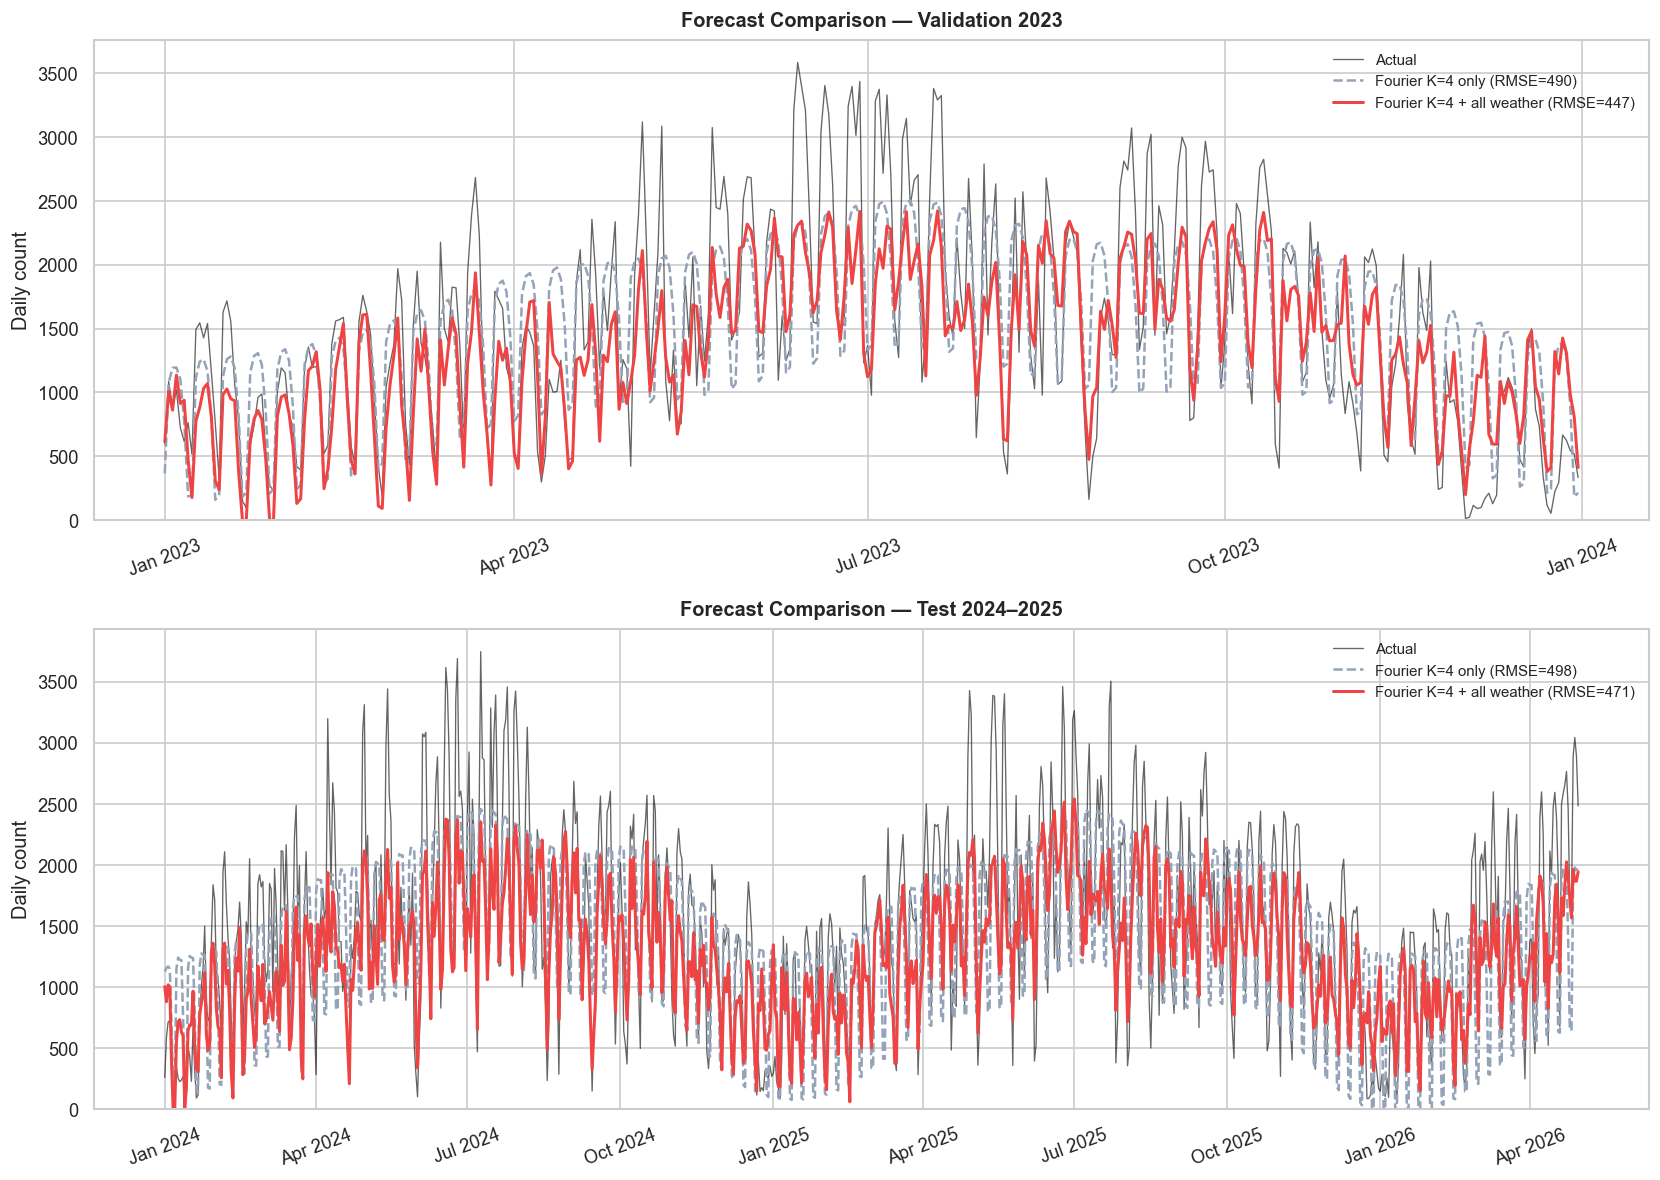

  saved → results/figures/nb05_fig_04_weather_forecast_comparison.png


In [12]:
# ── 2-panel: val and test forecast comparison ────────────────────────────
base_vp = fit_store['baseline']['val_preds']
base_tp = fit_store['baseline']['test_preds']
best_vp = fit_store[best_cfg_id]['val_preds']
best_tp = fit_store[best_cfg_id]['test_preds']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, (period_name, actual, base_p, best_p) in zip(axes, [
    ('Validation 2023', val,  base_vp, best_vp),
    ('Test 2024–2025',  test, base_tp, best_tp),
]):
    ax.plot(actual.index, actual.values, color='black', lw=0.8, alpha=0.6, label='Actual')
    rmse_base = evaluate_forecast(actual.values, base_p, 7)['RMSE']
    rmse_best = evaluate_forecast(actual.values, best_p, 7)['RMSE']
    ax.plot(actual.index, base_p, color='#94a3b8', lw=1.5, ls='--',
            label=f'Fourier K={OPTIMAL_K} only (RMSE={rmse_base:.0f})')
    ax.plot(actual.index, best_p, color='#ef4444', lw=1.8,
            label=f'{best_cfg["label"]} (RMSE={rmse_best:.0f})')
    ax.set_title(f'Forecast Comparison — {period_name}', pad=8)
    ax.set_ylabel('Daily count')
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=20)

plt.tight_layout()
savefig('fig_04_weather_forecast_comparison')

---
## Part 8 — Final Comparison vs All Prior Baselines

In [13]:
# ── Load upstream benchmark values from saved tables ─────────────────────────
baseline_comp = pd.read_csv(TABLES / 'hirsch_baseline_comparison.csv')

def _get_rmse(model, horizon, split):
    row = baseline_comp[
        (baseline_comp['Model'] == model) &
        (baseline_comp['Horizon'] == horizon) &
        (baseline_comp['Split'] == split)
    ]
    return float(row['RMSE'].iloc[0]) if len(row) > 0 else np.nan

sn364_test7   = _get_rmse('SeasonalNaive-364',              '7-day',  'test')
sn364_test30  = _get_rmse('SeasonalNaive-364',              '30-day', 'test')
sarima_test7  = _get_rmse('SARIMA(1, 1, 1)(1, 0, 1, 7)',   '7-day',  'test')
sarima_test30 = _get_rmse('SARIMA(1, 1, 1)(1, 0, 1, 7)',   '30-day', 'test')

_f_row        = fourier_comp.loc[fourier_comp['K'] == OPTIMAL_K].iloc[0]
nb04_test7    = float(_f_row['test_7d_RMSE'])
nb04_test30   = float(_f_row['test_30d_RMSE'])

best_row = summary_df.iloc[0]

final_table = pd.DataFrame([
    {
        'Model'                        : 'SeasonalNaive-364',
        'Test 7d RMSE'                 : sn364_test7,
        'Test 30d RMSE'                : sn364_test30,
        'Improvement vs SeasonalNaive' : '—',
        'Notes'                        : 'Best naive baseline (notebook 03)',
    },
    {
        'Model'                        : 'SARIMA(1,1,1)(1,0,1)[7]',
        'Test 7d RMSE'                 : sarima_test7,
        'Test 30d RMSE'                : sarima_test30,
        'Improvement vs SeasonalNaive' : f'{(sn364_test7 - sarima_test7)/sn364_test7*100:+.1f}%',
        'Notes'                        : 'Pure SARIMA, no annual seasonality (nb03)',
    },
    {
        'Model'                        : f'SARIMAX + Fourier K={OPTIMAL_K}',
        'Test 7d RMSE'                 : nb04_test7,
        'Test 30d RMSE'                : nb04_test30,
        'Improvement vs SeasonalNaive' : f'{(sn364_test7 - nb04_test7)/sn364_test7*100:+.1f}%',
        'Notes'                        : f'SARIMAX + Fourier annual terms (nb04)',
    },
    {
        'Model'                        : f'SARIMAX + Fourier + Weather ({best_row["Weather vars"]})',
        'Test 7d RMSE'                 : best_row['Test 7d RMSE'],
        'Test 30d RMSE'                : best_row['Test 30d RMSE'],
        'Improvement vs SeasonalNaive' : f'{(sn364_test7 - best_row["Test 7d RMSE"])/sn364_test7*100:+.1f}%',
        'Notes'                        : 'Best weather model (this notebook)',
    },
])

print('=== Final Model Comparison — Hirsch Station ===')
print(final_table.to_string(index=False))

=== Final Model Comparison — Hirsch Station ===
                                                                Model  Test 7d RMSE  Test 30d RMSE Improvement vs SeasonalNaive                                     Notes
                                                    SeasonalNaive-364         662.1          687.4                            —         Best naive baseline (notebook 03)
                                              SARIMA(1,1,1)(1,0,1)[7]        1511.2         1519.8                      -128.2% Pure SARIMA, no annual seasonality (nb03)
                                                SARIMAX + Fourier K=4         497.8          507.9                       +24.8%     SARIMAX + Fourier annual terms (nb04)
SARIMAX + Fourier + Weather (max_temp, sunshine_hours, precipitation)         471.0          481.5                       +28.9%        Best weather model (this notebook)


In [14]:
# ── Save best model ──────────────────────────────────────────────────────
with open(MODELS / 'hirsch_sarimax_final.pkl', 'wb') as f:
    pickle.dump(fit_store[best_cfg_id]['fit_tv'], f)

# ── Save predictions (all configs, val + test) ────────────────────────────
preds_out = pd.DataFrame({
    'date'  : list(val.index)    + list(test.index),
    'actual': list(val.values)   + list(test.values),
    'split' : ['val'] * len(val) + ['test'] * len(test),
})
for cfg in MODEL_CONFIGS:
    cid = cfg['id']
    preds_out[f'pred_{cid}'] = (
        list(fit_store[cid]['val_preds']) + list(fit_store[cid]['test_preds'])
    )
preds_out.to_csv(PREDS / 'hirsch_sarimax_weather_preds.csv', index=False)

# ── Save weather comparison table ────────────────────────────────────────
final_table.to_csv(TABLES / 'hirsch_sarimax_final_comparison.csv', index=False)

print('Saved artifacts:')
print(f'  results/models/hirsch_sarimax_final.pkl          (best model, fit on train+val)')
print(f'  results/predictions/hirsch_sarimax_weather_preds.csv')
print(f'  results/tables/weather_comparison.csv')
print(f'  results/tables/hirsch_sarimax_final_comparison.csv')
print(f'  results/figures/nb05_fig_01 through nb05_fig_04')

Saved artifacts:
  results/models/hirsch_sarimax_final.pkl          (best model, fit on train+val)
  results/predictions/hirsch_sarimax_weather_preds.csv
  results/tables/weather_comparison.csv
  results/tables/hirsch_sarimax_final_comparison.csv
  results/figures/nb05_fig_01 through nb05_fig_04


---
## Summary

### What we tested
Six SARIMAX configurations all sharing `(2,1,2)(1,0,2)[7] + Fourier K=4` as the base:

| Config | Weather added |
|--------|---------------|
| baseline | none |
| max_temp | max daily temperature (°C) |
| sunshine_hours | daily sunshine hours |
| precipitation | log1p(daily precipitation mm) |
| temp_sun | max_temp + sunshine_hours |
| all_weather | max_temp + sunshine_hours + precipitation |

### Decision criteria applied
- Keep if val RMSE improves >3% **and** p-value <0.05
- Drop if improvement <1% or test RMSE worsens
